In [227]:
import pandas as pd

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

df.head()
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [228]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [229]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,7590-VHVEG,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [230]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [231]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [232]:
df["Churn"].value_counts(normalize=True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

In [233]:
df[['MonthlyCharges','SeniorCitizen','tenure']].describe().T

,count,mean,std,min,25%,50%,75%,max
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.5,70.35,89.85,118.75
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.0,0.00,0.00,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.0,29.00,55.00,72.00


array([[<Axes: title={'center': 'SeniorCitizen'}>,
        <Axes: title={'center': 'tenure'}>],
       [<Axes: title={'center': 'MonthlyCharges'}>, <Axes: >]],
      dtype=object)

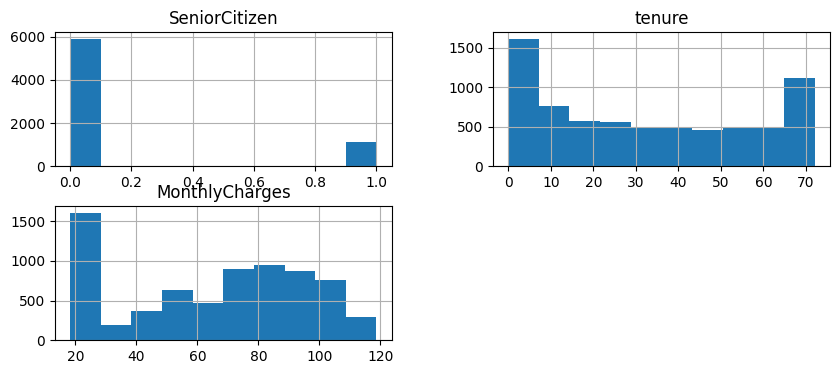

In [234]:
df[["SeniorCitizen", "tenure", "MonthlyCharges"]].hist(figsize=(10, 4))

In [235]:
import matplotlib.pyplot as plt

In [236]:
import seaborn as sns

<Axes: xlabel='Churn', ylabel='tenure'>

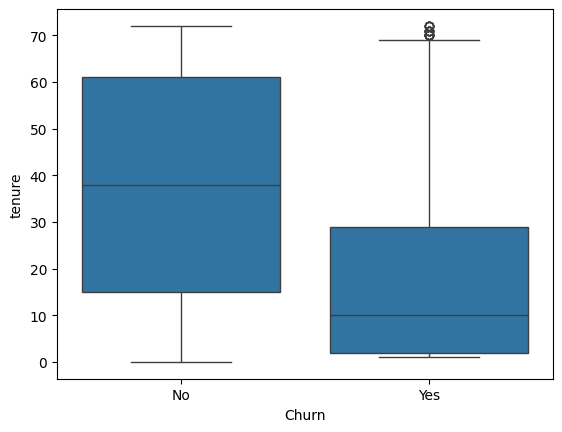

In [237]:
sns.boxplot(x='Churn',y='tenure',data=df)

<Axes: xlabel='Churn', ylabel='MonthlyCharges'>

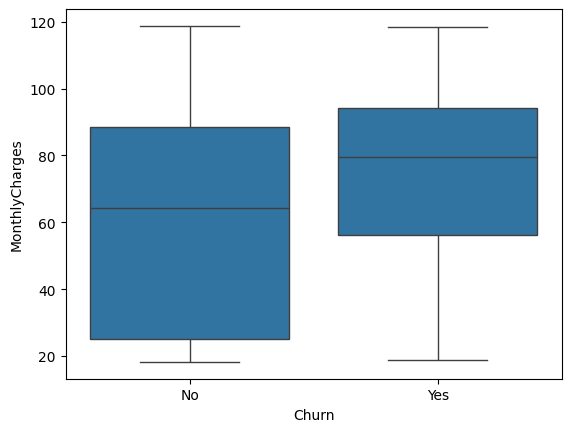

In [238]:
sns.boxplot(y='MonthlyCharges',x='Churn',data=df)

In [239]:
df["TotalCharges"].value_counts().head(20)

TotalCharges
20.2     11
         11
19.75     9
19.65     8
19.9      8
20.05     8
19.55     7
45.3      7
19.45     6
20.25     6
20.15     6
20.45     5
20.3      5
19.4      4
75.3      4
44.4      4
19.3      4
19.85     4
20.5      4
70.6      4
Name: count, dtype: int64

In [240]:
df["TotalCharges"].str.strip().eq("").sum()

np.int64(11)

In [241]:
df[df['TotalCharges'].str.strip()==""][['tenure','MonthlyCharges','Churn']]

,tenure,MonthlyCharges,Churn
488,0,52.55,No
753,0,20.25,No
936,0,80.85,No
1082,0,25.75,No
1340,0,56.05,No
3331,0,19.85,No
3826,0,25.35,No
4380,0,20.00,No
5218,0,19.70,No
6670,0,73.35,No


In [242]:
df['TotalCharges']=pd.to_numeric(df['TotalCharges'],errors='coerce')

In [243]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [244]:
df['TotalCharges']=df['TotalCharges'].fillna(0)

In [245]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [246]:
df['TotalCharges'].isnull().sum()

np.int64(0)

In [247]:
df['TotalCharges'].dtypes

dtype('float64')

In [248]:
pd.crosstab(df['Contract'],df['Churn'],normalize='index')*100

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


<Axes: xlabel='Contract', ylabel='count'>

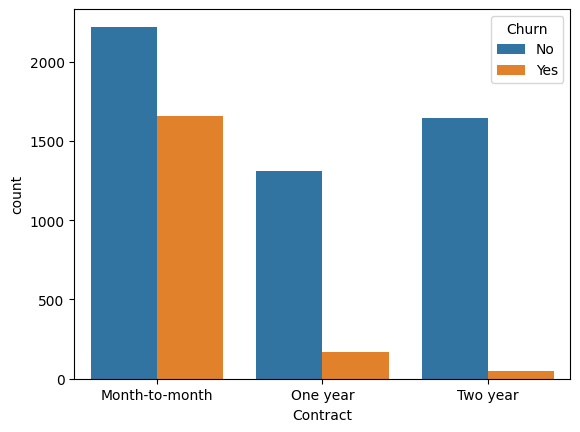

In [249]:
sns.countplot(x='Contract',hue='Churn',data=df)

In [250]:
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


In [251]:
pd.crosstab(df['InternetService'],df['Churn'],normalize='index')*100

Churn,No,Yes
InternetService,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


<Axes: xlabel='InternetService', ylabel='count'>

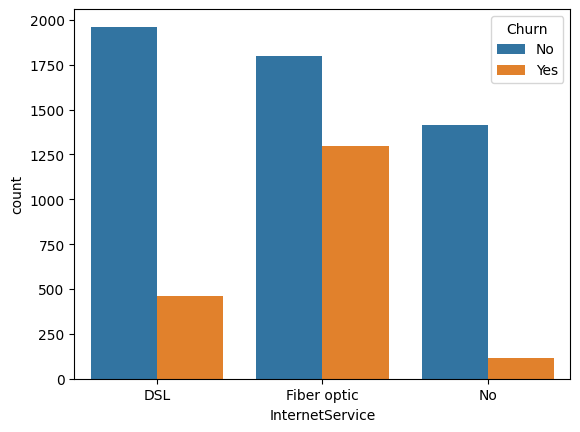

In [252]:
sns.countplot(x='InternetService',data=df,hue='Churn')

In [253]:
pd.crosstab(
    df["PaymentMethod"],
    df["Churn"],
    normalize="index"
) * 100

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


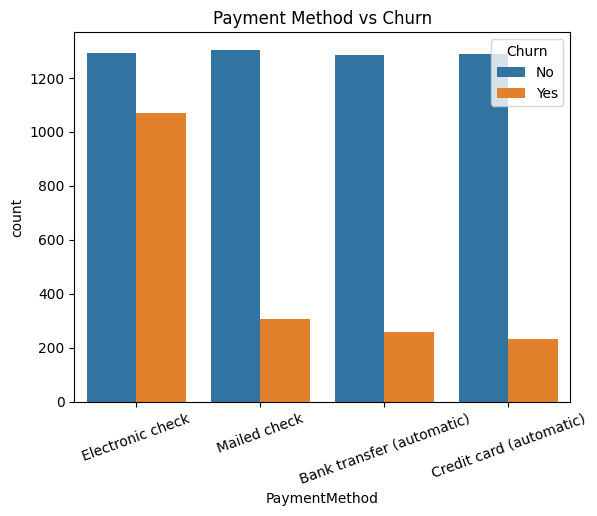

In [254]:
sns.countplot(data=df, x="PaymentMethod", hue="Churn")

plt.title("Payment Method vs Churn")
plt.xticks(rotation=20)
plt.show()

In [256]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [257]:
for col in ['OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport']:
    print(f"\n{col}")
    print(pd.crosstab(df[col],df['Churn'],normalize='index')*100)


OnlineSecurity
Churn                       No        Yes
OnlineSecurity                           
No                   58.233276  41.766724
No internet service  92.595020   7.404980
Yes                  85.388806  14.611194

OnlineBackup
Churn                       No        Yes
OnlineBackup                             
No                   60.071244  39.928756
No internet service  92.595020   7.404980
Yes                  78.468506  21.531494

DeviceProtection
Churn                       No        Yes
DeviceProtection                         
No                   60.872375  39.127625
No internet service  92.595020   7.404980
Yes                  77.497936  22.502064

TechSupport
Churn                       No        Yes
TechSupport                              
No                   58.364526  41.635474
No internet service  92.595020   7.404980
Yes                  84.833659  15.166341


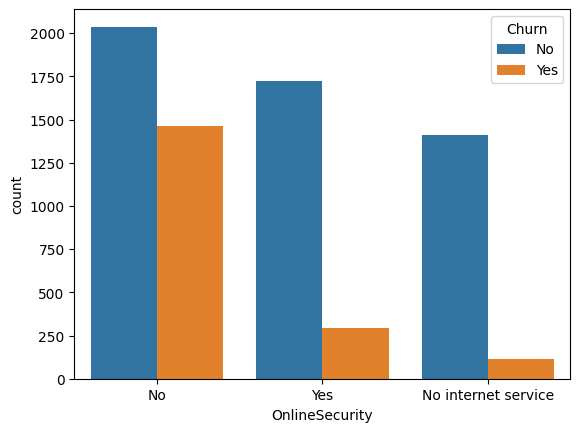

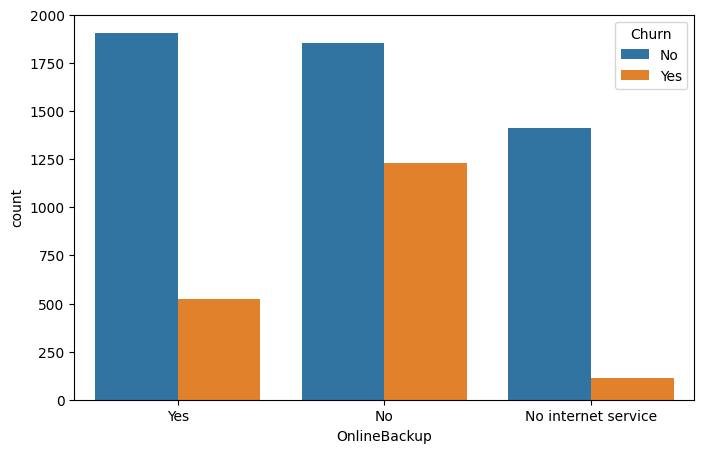

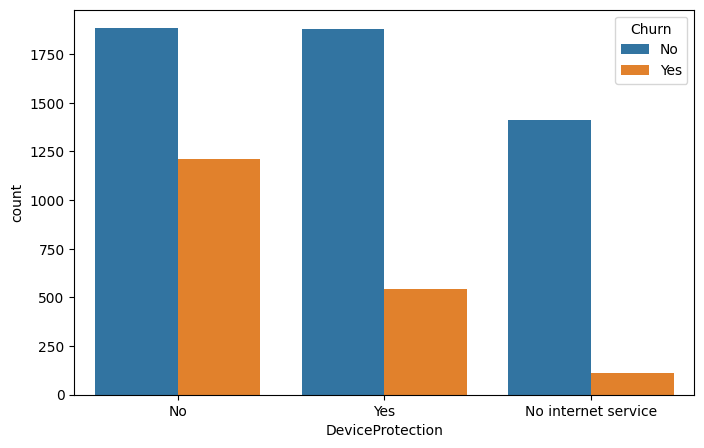

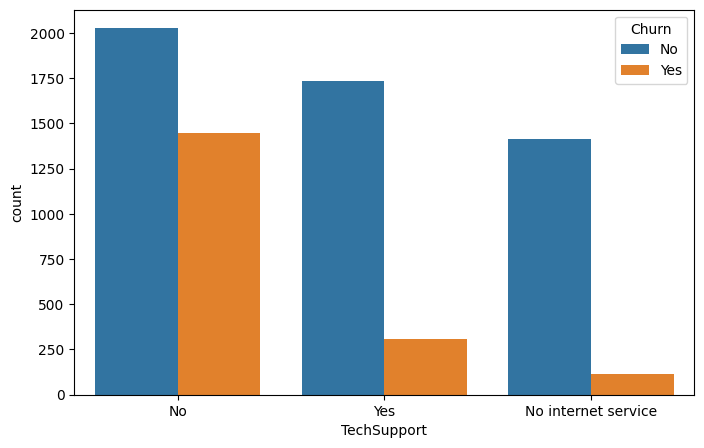

<Figure size 800x500 with 0 Axes>

In [258]:
for col in ['OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport']:
    sns.countplot(x=col,data=df,hue='Churn')
    plt.figure(figsize=(8,5))

In [259]:
cat_col=df.select_dtypes(include='object').columns.drop(['customerID','Churn'])

In [260]:
cat_col

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')

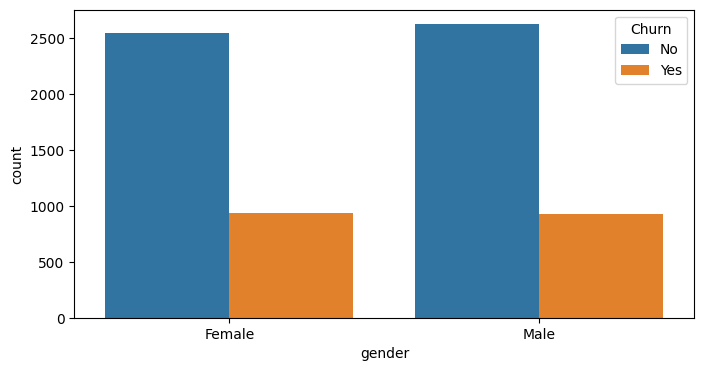

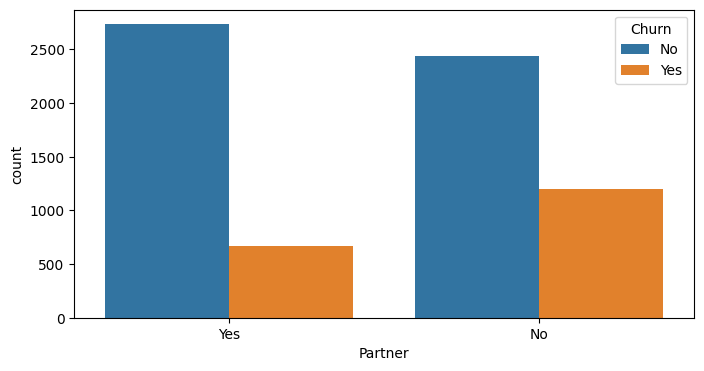

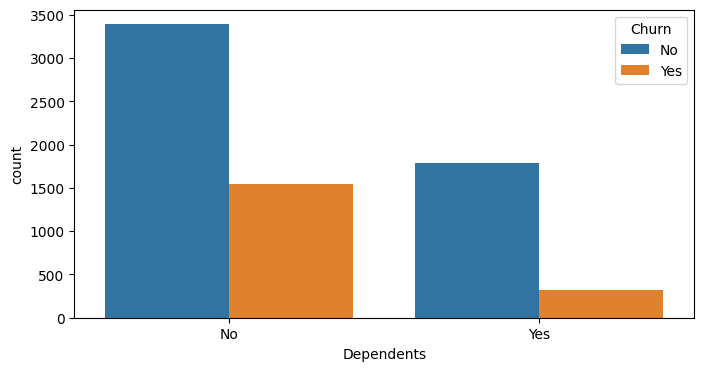

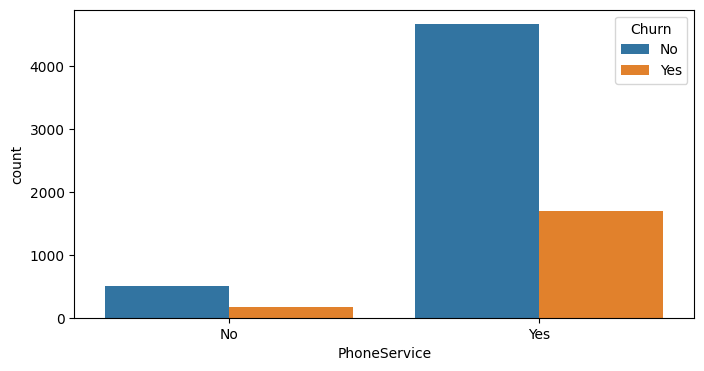

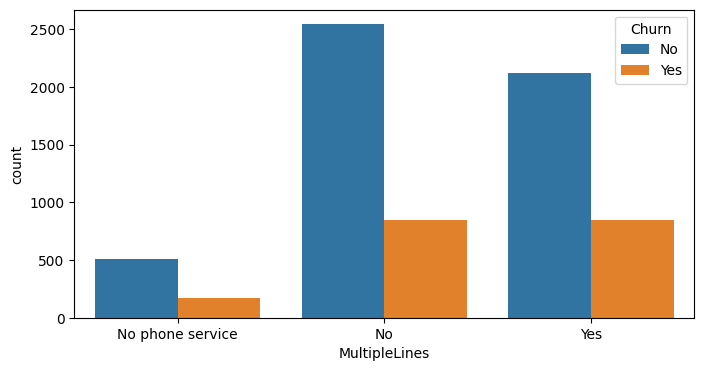

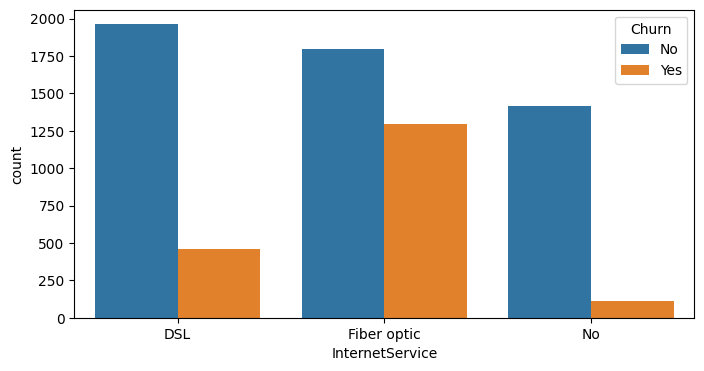

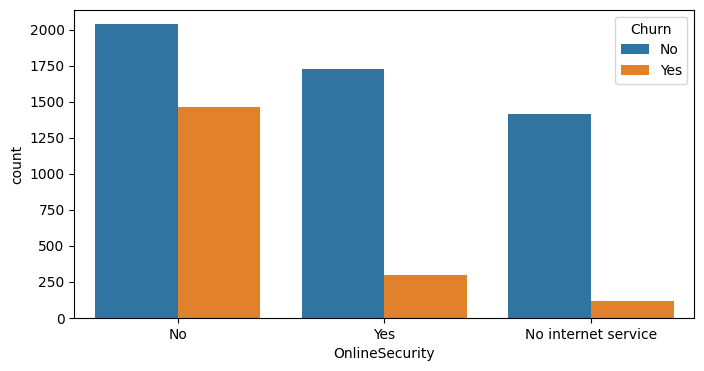

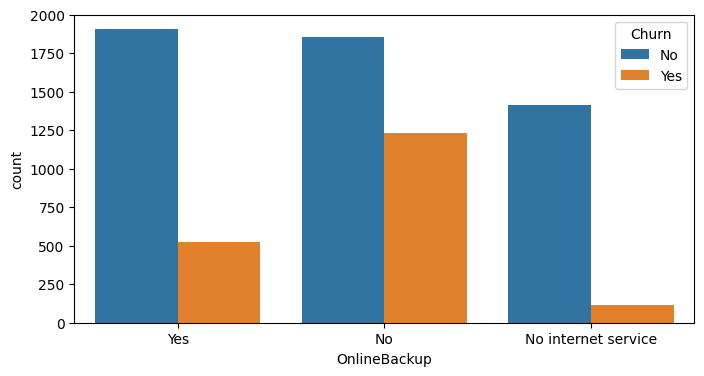

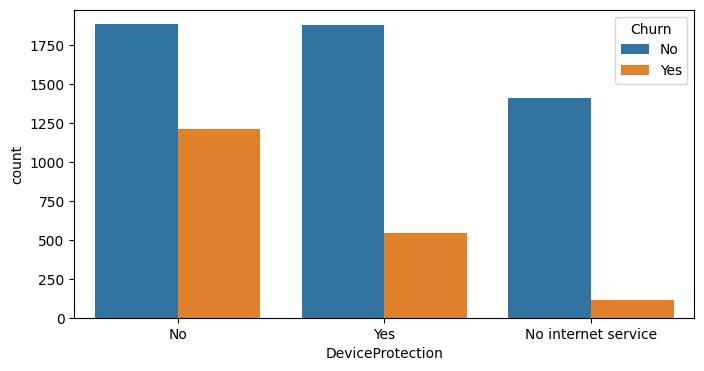

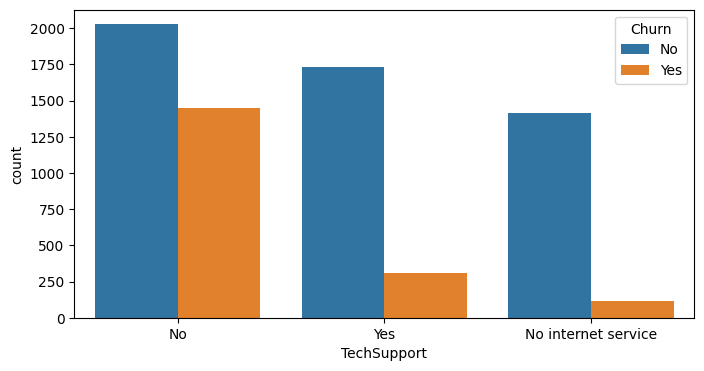

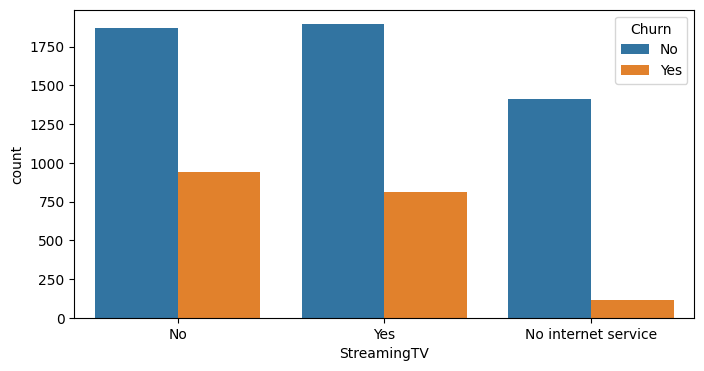

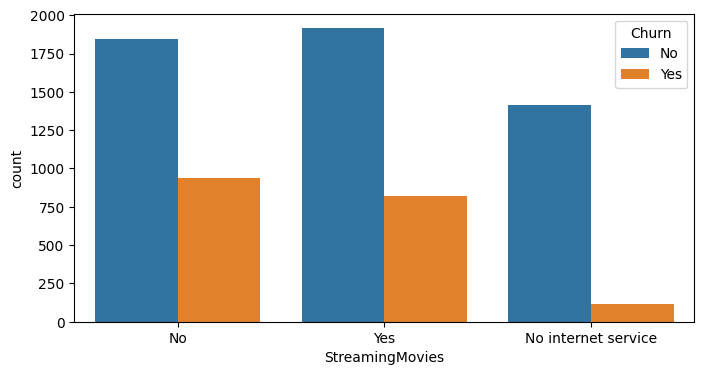

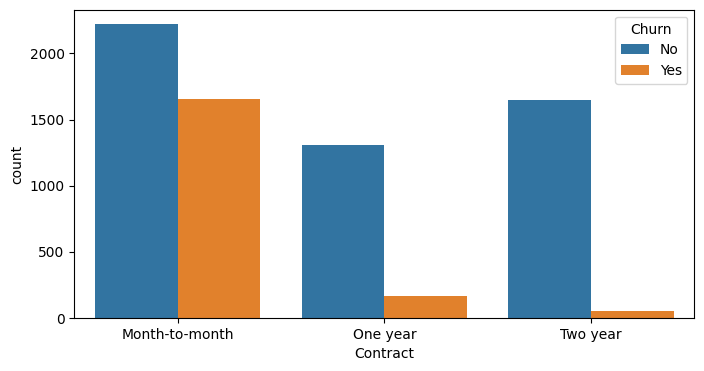

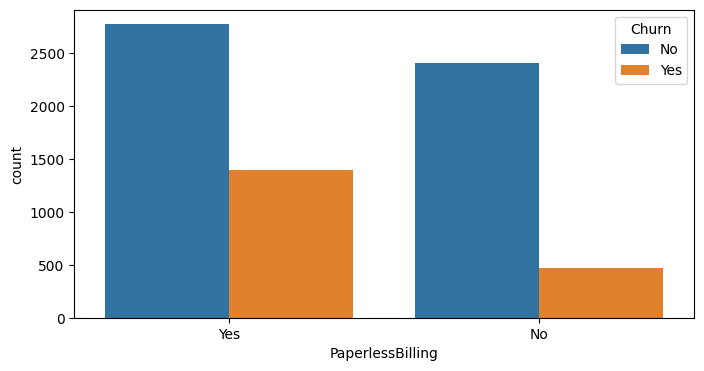

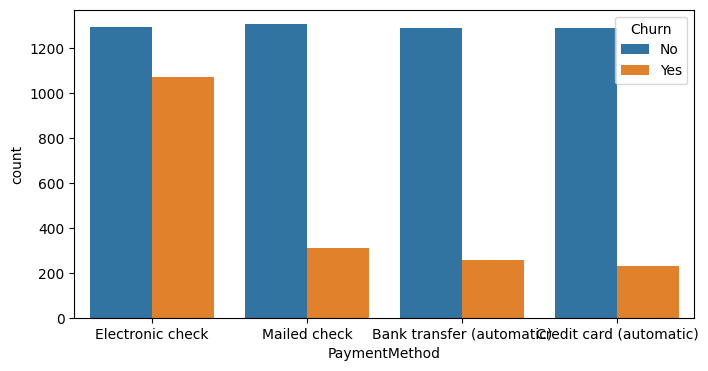

In [261]:
for col in cat_col:
    plt.figure(figsize=(8,4))
    sns.countplot(x=col,data=df,hue='Churn')

In [262]:
corr=df.corr(numeric_only=True)

<Axes: >

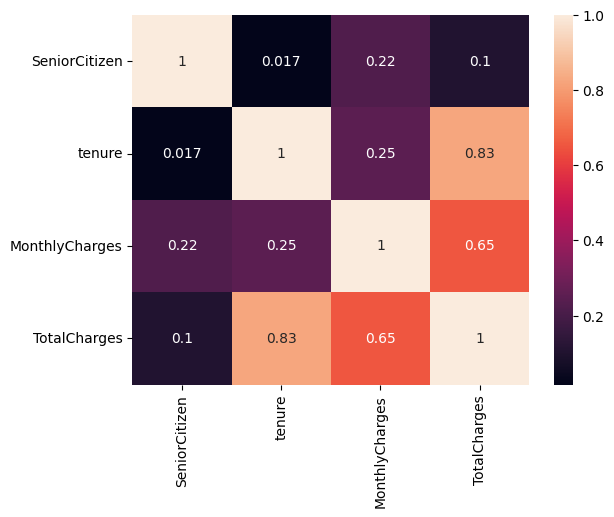

In [263]:
sns.heatmap(corr,annot=True)

## ML

In [264]:
num_cols = X.select_dtypes(include="number").columns
cat_cols = X.select_dtypes(include="object").columns

In [265]:
print(num_cols)

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')


In [266]:
from sklearn.model_selection import train_test_split

In [267]:
from sklearn.preprocessing import StandardScaler,OneHotEncoder

In [268]:
from sklearn.compose import ColumnTransformer

In [269]:
preprocessor=ColumnTransformer(
    transformers=[
        ('num',StandardScaler(),num_cols),
        ('cat',OneHotEncoder(drop='first',handle_unknown='ignore'),cat_cols)
    ])

In [270]:
X=df.drop(columns=['customerID','Churn'])

In [271]:
y=df['Churn'].map({'Yes':1,'No':0})

In [272]:
X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=42,test_size=0.2,stratify=y)

In [273]:
X_train_transformed=preprocessor.fit_transform(X_train)

In [274]:
X_test_transformed=preprocessor.transform(X_test)

In [275]:
X_train_transformed.shape

(5634, 30)

In [276]:
X_test_transformed.shape

(1409, 30)

In [277]:
features=preprocessor.get_feature_names_out()

In [278]:
features.shape

(30,)

In [279]:
features

array(['num__SeniorCitizen', 'num__tenure', 'num__MonthlyCharges',
       'num__TotalCharges', 'cat__gender_Male', 'cat__Partner_Yes',
       'cat__Dependents_Yes', 'cat__PhoneService_Yes',
       'cat__MultipleLines_No phone service', 'cat__MultipleLines_Yes',
       'cat__InternetService_Fiber optic', 'cat__InternetService_No',
       'cat__OnlineSecurity_No internet service',
       'cat__OnlineSecurity_Yes', 'cat__OnlineBackup_No internet service',
       'cat__OnlineBackup_Yes',
       'cat__DeviceProtection_No internet service',
       'cat__DeviceProtection_Yes',
       'cat__TechSupport_No internet service', 'cat__TechSupport_Yes',
       'cat__StreamingTV_No internet service', 'cat__StreamingTV_Yes',
       'cat__StreamingMovies_No internet service',
       'cat__StreamingMovies_Yes', 'cat__Contract_One year',
       'cat__Contract_Two year', 'cat__PaperlessBilling_Yes',
       'cat__PaymentMethod_Credit card (automatic)',
       'cat__PaymentMethod_Electronic check',
       '

In [280]:
X_train_df = pd.DataFrame(
    X_train_transformed,
    columns=features
)

In [281]:
X_train_df.head()

,num__SeniorCitizen,num__tenure,num__MonthlyCharges,num__TotalCharges,cat__gender_Male,cat__Partner_Yes,cat__Dependents_Yes,cat__PhoneService_Yes,cat__MultipleLines_No phone service,cat__MultipleLines_Yes,...,cat__StreamingTV_No internet service,cat__StreamingTV_Yes,cat__StreamingMovies_No internet service,cat__StreamingMovies_Yes,cat__Contract_One year,cat__Contract_Two year,cat__PaperlessBilling_Yes,cat__PaymentMethod_Credit card (automatic),cat__PaymentMethod_Electronic check,cat__PaymentMethod_Mailed check
0,-0.441773,0.102371,-0.521976,-0.262257,1.0,0.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1,-0.441773,-0.711743,0.337478,-0.503635,1.0,1.0,1.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,-0.441773,-0.793155,-0.809013,-0.749883,1.0,1.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
3,-0.441773,-0.263980,0.284384,-0.172722,0.0,1.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0
4,-0.441773,-1.281624,-0.676279,-0.989374,1.0,1.0,1.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [282]:
from sklearn.linear_model import LogisticRegression

In [283]:
logistic=LogisticRegression(random_state=42)

In [284]:
logistic.fit(X_train_transformed,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [285]:
y_pred=logistic.predict(X_test_transformed)

In [286]:
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score

In [287]:
confusion_matrix(y_test,y_pred)

array([[927, 108],
       [164, 210]])

In [288]:
print(accuracy_score(y_test,y_pred))

0.8069552874378992


In [289]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.90      0.87      1035
           1       0.66      0.56      0.61       374

    accuracy                           0.81      1409
   macro avg       0.76      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



In [290]:
from sklearn.ensemble import RandomForestClassifier

In [291]:
rf=RandomForestClassifier(n_estimators=200,random_state=42)

In [292]:
rf.fit(X_train_transformed,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [293]:
y_pred_rf=rf.predict(X_test_transformed)

In [294]:
accuracy_score(y_test,y_pred_rf)

0.7899219304471257

In [295]:
confusion_matrix(y_test,y_pred_rf)

array([[923, 112],
       [184, 190]])

In [296]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1035
           1       0.63      0.51      0.56       374

    accuracy                           0.79      1409
   macro avg       0.73      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409



In [297]:
from xgboost import XGBClassifier

In [298]:
xgb=XGBClassifier(n_estimators=100,learning_rate=0.1,max_depth=3,random_state=42)

In [299]:
xgb.fit(X_train_transformed,y_train)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_meth

In [300]:
y_pred_xgb=xgb.predict(X_test_transformed)

In [301]:
accuracy_score(y_test,y_pred_xgb)

0.8005677785663591

In [302]:
confusion_matrix(y_test,y_pred_xgb)

array([[933, 102],
       [179, 195]])

In [303]:
print(classification_report(y_test,y_pred_xgb))

              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.66      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.73      1409
weighted avg       0.79      0.80      0.79      1409



In [304]:
from lightgbm import LGBMClassifier

In [305]:
lgbm = LGBMClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

In [306]:
lgbm.fit(X_train_transformed,y_train)

[LightGBM] [Info] Number of positive: 1495, number of negative: 4139
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000843 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 639
[LightGBM] [Info] Number of data points in the train set: 5634, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.265353 -> initscore=-1.018328
[LightGBM] [Info] Start training from score -1.018328
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,3
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [307]:
y_pred_lgbm=lgbm.predict(X_test_transformed)

In [308]:
accuracy_score(y_test,y_pred_lgbm)

0.794889992902768

In [309]:
confusion_matrix(y_test,y_pred_lgbm)

array([[926, 109],
       [180, 194]])

In [310]:
print(classification_report(y_test,y_pred_lgbm))

              precision    recall  f1-score   support

           0       0.84      0.89      0.87      1035
           1       0.64      0.52      0.57       374

    accuracy                           0.79      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.78      0.79      0.79      1409



In [311]:
from sklearn.tree import DecisionTreeClassifier

In [312]:
dt=DecisionTreeClassifier(max_depth=5,random_state=42)

In [313]:
dt.fit(X_train_transformed,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

In [314]:
y_pred_dt=dt.predict(X_test_transformed)

In [315]:
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))
print("\nClassification Report:\n", classification_report(y_test, y_pred_dt))

Accuracy: 0.794180269694819

Confusion Matrix:
 [[917 118]
 [172 202]]

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.89      0.86      1035
           1       0.63      0.54      0.58       374

    accuracy                           0.79      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.79      0.79      1409



In [316]:
from sklearn.metrics import roc_auc_score,roc_curve

In [317]:
y_pred_lr=logistic.predict_proba(X_test_transformed)[:,1]

In [318]:
roc_auc_lr = roc_auc_score(y_test, y_pred_lr)

In [319]:
print("Logistic Regression ROC-AUC:", roc_auc_lr)

Logistic Regression ROC-AUC: 0.8421710713270816


In [320]:
y_prob_rf = rf.predict_proba(X_test_transformed)[:, 1]

roc_auc_rf = roc_auc_score(y_test, y_prob_rf)

print("Random Forest ROC-AUC:", roc_auc_rf)

Random Forest ROC-AUC: 0.8259074117130384


In [321]:
y_prob_xgb = xgb.predict_proba(X_test_transformed)[:, 1]

roc_auc_xgb = roc_auc_score(y_test, y_prob_xgb)

print("XGBoost ROC-AUC:", roc_auc_xgb)

XGBoost ROC-AUC: 0.8446369061458576


In [322]:
y_prob_lgbm = lgbm.predict_proba(X_test_transformed)[:, 1]

roc_auc_lgbm = roc_auc_score(y_test, y_prob_lgbm)

print("LightGBM ROC-AUC:", roc_auc_lgbm)

LightGBM ROC-AUC: 0.8452310832106229


In [323]:
y_prob_dt = dt.predict_proba(X_test_transformed)[:, 1]

roc_auc_dt = roc_auc_score(y_test, y_prob_dt)

print("Decision Tree ROC-AUC:", roc_auc_dt)

Decision Tree ROC-AUC: 0.8267043839933865


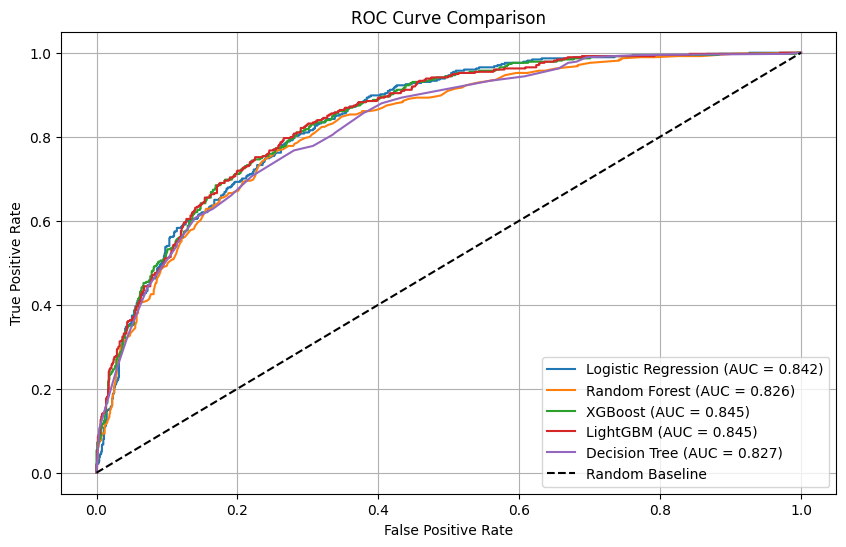

In [324]:
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_pred_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)
fpr_lgbm, tpr_lgbm, _ = roc_curve(y_test, y_prob_lgbm)
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)

# Plotting ROC Curves
plt.figure(figsize=(10, 6))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {roc_auc_lr:.3f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_rf:.3f})')
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {roc_auc_xgb:.3f})')
plt.plot(fpr_lgbm, tpr_lgbm, label=f'LightGBM (AUC = {roc_auc_lgbm:.3f})')
plt.plot(fpr_dt, tpr_dt, label=f'Decision Tree (AUC = {roc_auc_dt:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Baseline')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

In [325]:
from sklearn.metrics import average_precision_score

In [326]:
pr_auc_lr = average_precision_score(y_test, y_pred_lr)

In [327]:
pr_auc_lr

0.635014959434485

In [328]:
pr_auc_rf = average_precision_score(y_test, y_prob_rf)

print("Random Forest PR-AUC:", pr_auc_rf)

Random Forest PR-AUC: 0.6249195500649014


In [329]:
pr_auc_dt = average_precision_score(y_test, y_prob_dt)

print("DT PR-AUC:", pr_auc_dt)

DT PR-AUC: 0.6222322549542372


In [330]:
pr_auc_xgb=average_precision_score(y_test,y_pred_xgb)
print("XGB: ",pr_auc_xgb)

XGB:  0.4693674676728612


In [331]:
pr_auc_lgb=average_precision_score(y_test,y_prob_lgbm)
print("LGB: ",pr_auc_lgb)

LGB:  0.6661538099916336


In [332]:
pr_auc_xgb = average_precision_score(y_test, y_prob_xgb)

print("XGBoost PR-AUC:", pr_auc_xgb)

XGBoost PR-AUC: 0.6624763225666439


In [333]:
pr_auc_scores = {
    "Logistic Regression": pr_auc_lr,
    "Random Forest": pr_auc_rf,
    "Decision Tree": pr_auc_dt,
    "XGBoost": pr_auc_xgb,
    "LightGBM": pr_auc_lgb
}

pr_auc_scores

{'Logistic Regression': 0.635014959434485,
 'Random Forest': 0.6249195500649014,
 'Decision Tree': 0.6222322549542372,
 'XGBoost': 0.6624763225666439,
 'LightGBM': 0.6661538099916336}

In [334]:
from sklearn.metrics import precision_recall_curve

In [335]:
precision_lr, recall_lr, _ = precision_recall_curve(y_test, y_pred_lr)
precision_rf, recall_rf, _ = precision_recall_curve(y_test, y_prob_rf)
precision_xgb, recall_xgb, _ = precision_recall_curve(y_test, y_prob_xgb)
precision_lgbm, recall_lgbm, _ = precision_recall_curve(y_test, y_prob_lgbm)
precision_dt, recall_dt, _ = precision_recall_curve(y_test, y_prob_dt)

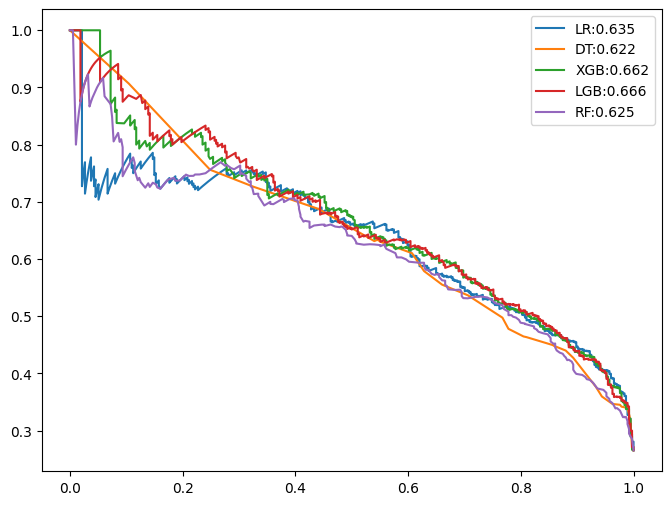

In [336]:
plt.figure(figsize=(8,6))
plt.plot(recall_lr,precision_lr,label=f"LR:{pr_auc_lr:.3f}")
plt.plot(recall_dt,precision_dt,label=f"DT:{pr_auc_dt:.3f}")
plt.plot(recall_xgb,precision_xgb,label=f"XGB:{pr_auc_xgb:.3f}")
plt.plot(recall_lgbm,precision_lgbm,label=f"LGB:{pr_auc_lgb:.3f}")
plt.plot(recall_rf,precision_rf,label=f"RF:{pr_auc_rf:.3f}")
plt.legend()

In [337]:
comparision=pd.DataFrame({
    "Model":['LR','RF','XGB','LGB','DT'],
    "ROC_AUC":[roc_auc_lr,roc_auc_rf,roc_auc_xgb,roc_auc_lgbm,roc_auc_dt],
    "PR":[pr_auc_lr,pr_auc_rf,pr_auc_xgb,pr_auc_lgb,pr_auc_dt]
})

In [338]:
comparision.sort_values("PR",ascending=False)

,Model,ROC_AUC,PR
3,LGB,0.845231,0.666154
2,XGB,0.844637,0.662476
0,LR,0.842171,0.635015
1,RF,0.825907,0.624920
4,DT,0.826704,0.622232


In [339]:
print(classification_report(y_test, y_pred_xgb))
confusion_matrix(y_test, y_pred_xgb)

              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.66      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.73      1409
weighted avg       0.79      0.80      0.79      1409



array([[933, 102],
       [179, 195]])

In [340]:
y_pred_xgb_2=(y_prob_xgb>=0.4).astype(int)

In [341]:
confusion_matrix(y_test,y_pred_xgb_2)

array([[861, 174],
       [121, 253]])

In [342]:
print(classification_report(y_test, y_pred_xgb_2))
confusion_matrix(y_test, y_pred_xgb_2)

              precision    recall  f1-score   support

           0       0.88      0.83      0.85      1035
           1       0.59      0.68      0.63       374

    accuracy                           0.79      1409
   macro avg       0.73      0.75      0.74      1409
weighted avg       0.80      0.79      0.79      1409



array([[861, 174],
       [121, 253]])

In [343]:
for i in [0.3, 0.4, 0.5, 0.6]:
    y_prediction=(y_prob_xgb>=i).astype(int)
    print(f"Confussion metrix: {i} {confusion_matrix(y_test,y_prediction)}")

Confussion metrix: 0.3 [[772 263]
 [ 86 288]]
Confussion metrix: 0.4 [[861 174]
 [121 253]]
Confussion metrix: 0.5 [[933 102]
 [179 195]]
Confussion metrix: 0.6 [[982  53]
 [242 132]]


In [344]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

thresholds = [0.3, 0.4, 0.5, 0.6]

for t in thresholds:
    pred = (y_prob_xgb >= t).astype(int)

    print(f"\nThreshold: {t}")
    print("Accuracy :", accuracy_score(y_test, pred))
    print("Precision:", precision_score(y_test, pred))
    print("Recall   :", recall_score(y_test, pred))
    print("F1       :", f1_score(y_test, pred))


Threshold: 0.3
Accuracy : 0.752306600425834
Precision: 0.5226860254083484
Recall   : 0.7700534759358288
F1       : 0.6227027027027027

Threshold: 0.4
Accuracy : 0.7906316536550745
Precision: 0.5925058548009368
Recall   : 0.6764705882352942
F1       : 0.6317103620474407

Threshold: 0.5
Accuracy : 0.8005677785663591
Precision: 0.6565656565656566
Recall   : 0.5213903743315508
F1       : 0.5812220566318927

Threshold: 0.6
Accuracy : 0.7906316536550745
Precision: 0.7135135135135136
Recall   : 0.35294117647058826
F1       : 0.47227191413237923


In [222]:
import shap

In [346]:
explainer=shap.TreeExplainer(xgb)

In [347]:
shap_values=explainer.shap_values(X_train_transformed)

In [348]:
shap_values.shape

(5634, 30)

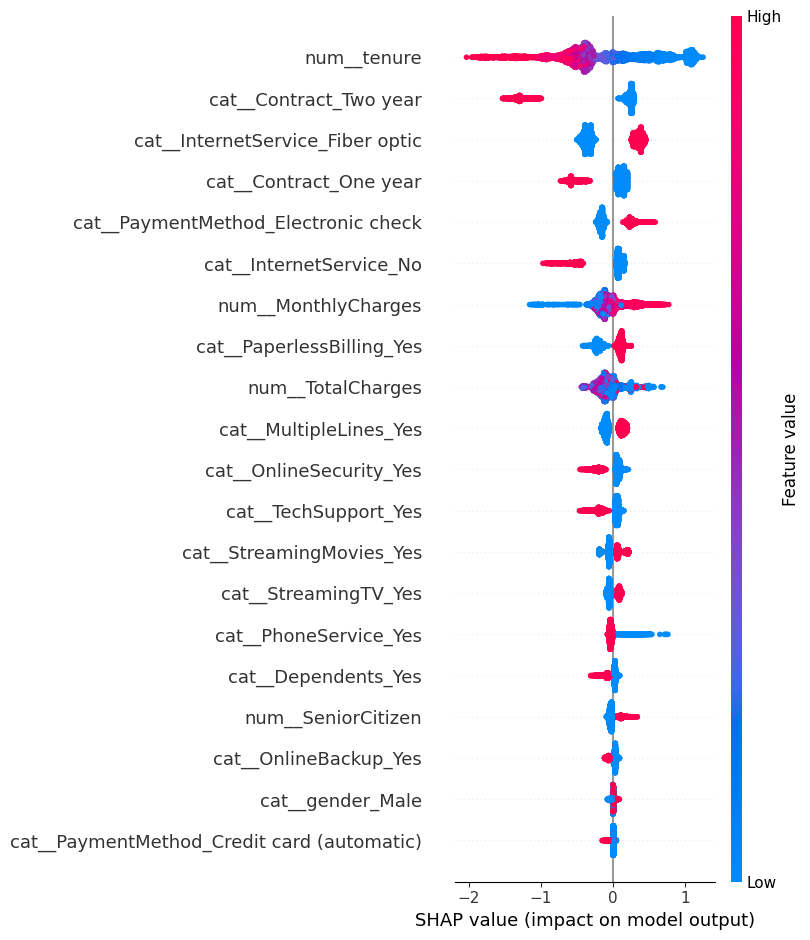

In [350]:
shap.summary_plot(
    shap_values,
    X_train_transformed,
    feature_names=features
)

In [351]:
shap_values

array([[-4.5445979e-02, -4.2391726e-01,  5.1435210e-02, ...,
         2.0353822e-02,  2.4314481e-01,  8.2177774e-04],
       [-4.8994794e-02,  4.6601303e-02, -9.1465645e-02, ...,
         2.3414053e-03, -1.8610795e-01, -1.9481491e-02],
       [-5.7426319e-02,  9.7569779e-02, -2.2390071e-01, ...,
         1.7790504e-02, -1.9017555e-01, -9.4969068e-03],
       ...,
       [ 2.1221980e-01, -9.0113118e-02,  3.7069651e-01, ...,
        -4.4089677e-03, -1.8282439e-01,  9.9131227e-02],
       [-3.7238542e-02, -2.2068630e-01, -1.5211289e-01, ...,
        -2.1292651e-02, -1.3348222e-01, -4.4894228e-03],
       [-5.9731442e-02,  3.4870043e-01, -1.8093930e-01, ...,
         3.1510645e-03, -1.4599279e-01, -2.1509593e-04]],
      shape=(5634, 30), dtype=float32)

In [352]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

In [357]:
smote_xgb=ImbPipeline([
    ('preprocessor',preprocessor),
    ('smote',SMOTE(random_state=42)),
    ('model',XGBClassifier(
        n_estimators=100,
        learning_rate=0.1,
        random_state=42,
        max_depth=3
    ))
])

In [358]:
smote_xgb.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The

In [359]:
y_pred_smote = smote_xgb.predict_proba(X_test)[:, 1]

In [360]:
y_pred_smote_class = (y_pred_smote >= 0.5).astype(int)

In [361]:
print(classification_report(y_test, y_pred_smote_class))

              precision    recall  f1-score   support

           0       0.87      0.80      0.84      1035
           1       0.55      0.67      0.61       374

    accuracy                           0.77      1409
   macro avg       0.71      0.74      0.72      1409
weighted avg       0.79      0.77      0.78      1409



In [362]:
roc_auc_smote = roc_auc_score(y_test, y_pred_smote)
pr_auc_smote = average_precision_score(y_test, y_pred_smote)

print("SMOTE + XGBoost ROC-AUC:", roc_auc_smote)
print("SMOTE + XGBoost PR-AUC:", pr_auc_smote)

SMOTE + XGBoost ROC-AUC: 0.8414916427704151
SMOTE + XGBoost PR-AUC: 0.6519701828540467


In [363]:
thresholds = [0.3, 0.4, 0.5, 0.6]

for threshold in thresholds:
    y_pred_threshold = (y_pred_smote >= threshold).astype(int)

    print(f"\nThreshold: {threshold}")
    print("Accuracy :", accuracy_score(y_test, y_pred_threshold))
    print("Precision:", precision_score(y_test, y_pred_threshold))
    print("Recall   :", recall_score(y_test, y_pred_threshold))
    print("F1       :", f1_score(y_test, y_pred_threshold))


Threshold: 0.3
Accuracy : 0.7068843151171044
Precision: 0.47093889716840537
Recall   : 0.8449197860962567
F1       : 0.6047846889952153

Threshold: 0.4
Accuracy : 0.759403832505323
Precision: 0.5316455696202531
Recall   : 0.786096256684492
F1       : 0.6343042071197411

Threshold: 0.5
Accuracy : 0.7693399574166075
Precision: 0.5538461538461539
Recall   : 0.6737967914438503
F1       : 0.6079613992762364

Threshold: 0.6
Accuracy : 0.7991483321504613
Precision: 0.6334310850439883
Recall   : 0.5775401069518716
F1       : 0.6041958041958042


In [364]:
y_pred_final=(y_pred_smote>=0.4).astype(int)

In [365]:
confusion_matrix(y_test,y_pred_final)

array([[776, 259],
       [ 80, 294]])

In [367]:
print(classification_report(y_test,y_pred_final))

              precision    recall  f1-score   support

           0       0.91      0.75      0.82      1035
           1       0.53      0.79      0.63       374

    accuracy                           0.76      1409
   macro avg       0.72      0.77      0.73      1409
weighted avg       0.81      0.76      0.77      1409



In [368]:
from sklearn.model_selection import cross_validate,StratifiedKFold

In [371]:
cv=StratifiedKFold(
    n_splits=5,
    random_state=42,
    shuffle=True
)

In [378]:
from sklearn.pipeline import Pipeline

In [379]:
pipeline=Pipeline([
    ('preprocessor',preprocessor),
    ('model',xgb)
])

In [382]:
cv_result=cross_validate(
    pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=['accuracy', 'precision', 'recall', 'f1', 'roc_auc'],
    n_jobs=-1
)

In [385]:
cv_result['test_accuracy'].mean()

np.float64(0.8054688645092758)

In [386]:
cv_df = pd.DataFrame({
    'Fold': [f'Fold {i+1}' for i in range(5)],
    'Accuracy': cv_result['test_accuracy'],
    'Precision': cv_result['test_precision'],
    'Recall': cv_result['test_recall'],
    'F1': cv_result['test_f1'],
    'ROC_AUC': cv_result['test_roc_auc']
})

cv_df

,Fold,Accuracy,Precision,Recall,F1,ROC_AUC
0,Fold 1,0.795031,0.650442,0.491639,0.560000,0.843399
1,Fold 2,0.789707,0.632479,0.494983,0.555347,0.829357
2,Fold 3,0.810115,0.679325,0.538462,0.600746,0.844976
3,Fold 4,0.815439,0.685714,0.561873,0.617647,0.861763
4,Fold 5,0.817052,0.720379,0.508361,0.596078,0.859160


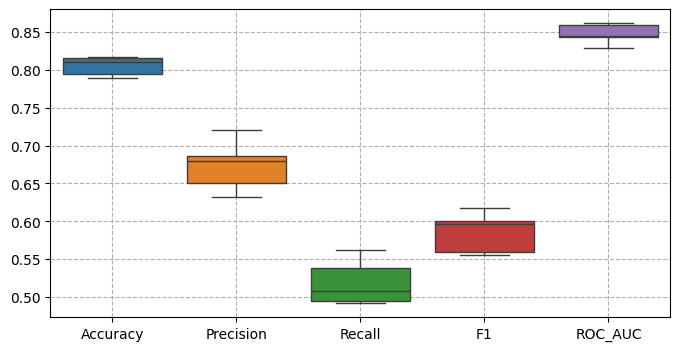

In [392]:
plt.figure(figsize=(8,4))
sns.boxplot(data=cv_df.drop(columns='Fold'))
plt.grid(True,linestyle='--')

In [395]:
cv_result=cross_validate(
    smote_xgb,
    X_train,
    y_train,
    scoring=['accuracy','precision','recall','f1','roc_auc'],
    n_jobs=-1
)

In [396]:
cv_result['test_accuracy'].mean()

np.float64(0.7900195586768185)

In [397]:
print("Accuracy :", cv_result['test_accuracy'].mean())
print("Precision:", cv_result['test_precision'].mean())
print("Recall   :", cv_result['test_recall'].mean())
print("F1       :", cv_result['test_f1'].mean())
print("ROC-AUC  :", cv_result['test_roc_auc'].mean())

Accuracy : 0.7900195586768185
Precision: 0.5902878938913529
Recall   : 0.6903010033444815
F1       : 0.6361496069620957
ROC-AUC  : 0.845459806487035


In [398]:
from sklearn.model_selection import RandomizedSearchCV

In [399]:
param_grid={
    'model__n_estimators':[100,150,200],
    'model__max_depth':[3,4,5],
    'model__learning_rate':[0.01, 0.05, 0.1]
}

In [400]:
random_search=RandomizedSearchCV(
    estimator=smote_xgb,
    param_distributions=param_grid,
    n_iter=10,
    n_jobs=-1,
    random_state=42,
    cv=cv
)

In [401]:
random_search.fit(X_train,y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__learning_rate': [0.01, 0.05, ...], 'model__max_depth': [3, 4, ...], 'model__n_estimators': [100, 150, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:

In [402]:
random_search.best_params_

{'model__n_estimators': 200,
 'model__max_depth': 5,
 'model__learning_rate': 0.05}

In [403]:
random_search.best_score_

np.float64(0.7918017465693513)

In [404]:
best_model=random_search.best_estimator_

In [405]:
best_model

,steps,"[('preprocessor', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The

In [406]:
best_model = random_search.best_estimator_
y_test_pred = best_model.predict(X_test)
y_test_prob = best_model.predict_proba(X_test)[:, 1]

print("--- Tuned Model Test Evaluation ---")
print("Accuracy :", accuracy_score(y_test, y_test_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_test_prob))
print("PR-AUC   :", average_precision_score(y_test, y_test_prob))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_test_pred))
print("\nClassification Report:\n", classification_report(y_test, y_test_pred))

--- Tuned Model Test Evaluation ---
Accuracy : 0.7757274662881476
ROC-AUC  : 0.8396096515022347
PR-AUC   : 0.6504916669027901

Confusion Matrix:
 [[859 176]
 [140 234]]

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.83      0.84      1035
           1       0.57      0.63      0.60       374

    accuracy                           0.78      1409
   macro avg       0.72      0.73      0.72      1409
weighted avg       0.78      0.78      0.78      1409

